Case 1: lambda=0.20, M_max=1000, stationary=[0.25 0.25 0.25 0.25], max|pi D|=0.000e+00, B_M=0.000000e+00, bound_M=0.000000e+00
Case 2: lambda=0.49, M_max=1100, stationary=[0.25 0.25 0.25 0.25], max|pi D|=1.110e-16, B_M=9.341365e-05, bound_M=7.878379e+01
Case 3: lambda=0.51, M_max=1010, stationary=[0.25 0.25 0.25 0.25], max|pi D|=5.551e-17, B_M=2.517372e+32, bound_M=1.730888e+38
Case 4: lambda=0.60, M_max=510, stationary=[0.25 0.25 0.25 0.25], max|pi D|=0.000e+00, B_M=2.456409e+103, bound_M=4.497747e+108
Saved 8 files to: /Users/lusmac/PycharmProjects/PythonProject/Translation/0713/Binomial_Bound
  Binomial_Bound/BM_real1.npy
  Binomial_Bound/BM_bound1.npy
  Binomial_Bound/BM_real2.npy
  Binomial_Bound/BM_bound2.npy
  Binomial_Bound/BM_real3.npy
  Binomial_Bound/BM_bound3.npy
  Binomial_Bound/BM_real4.npy
  Binomial_Bound/BM_bound4.npy


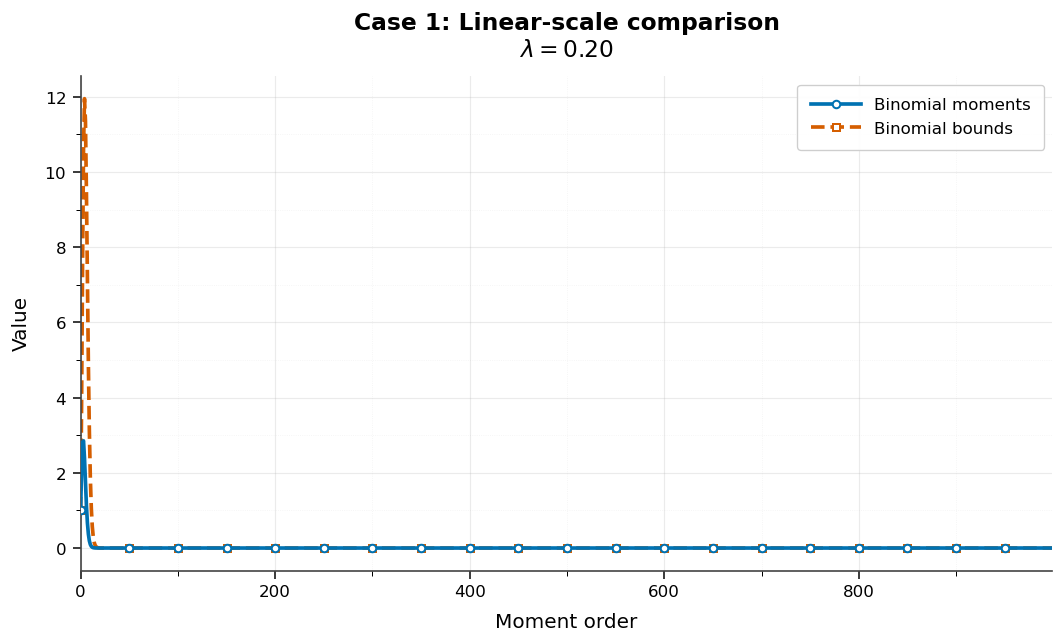

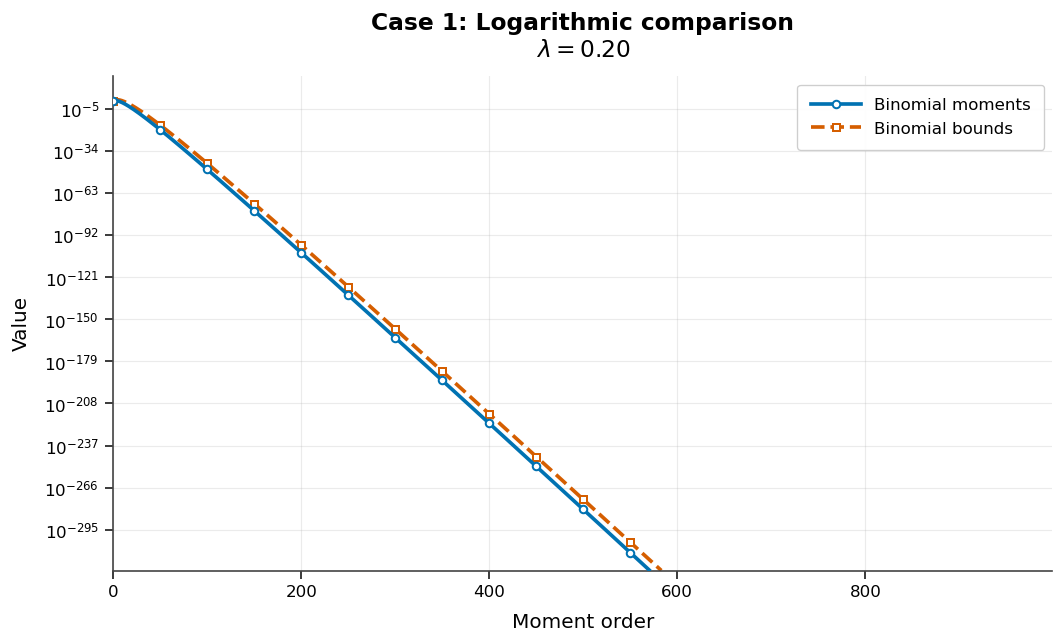

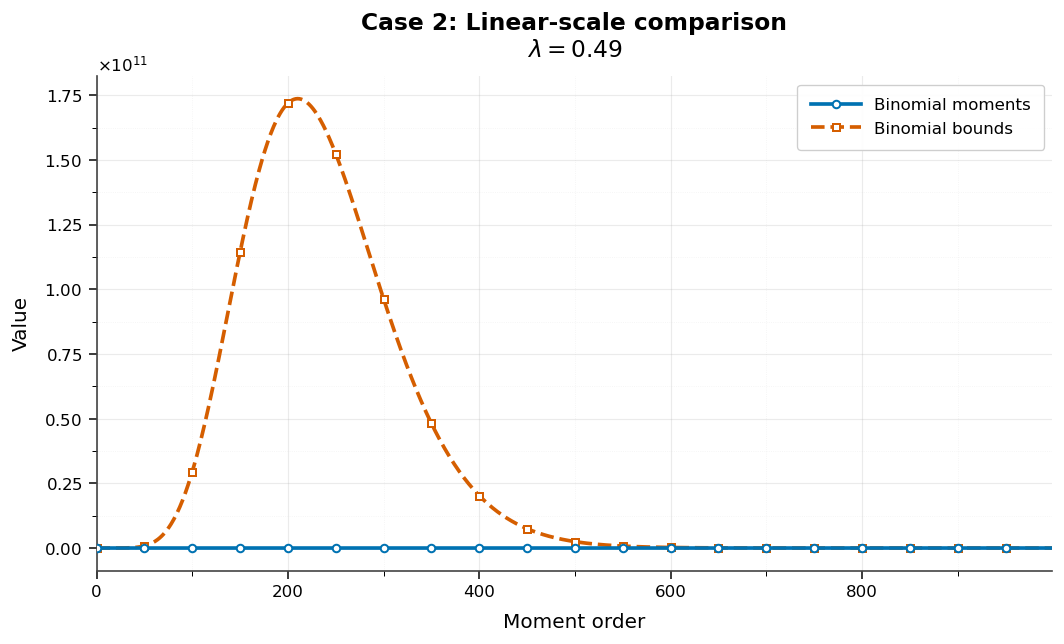

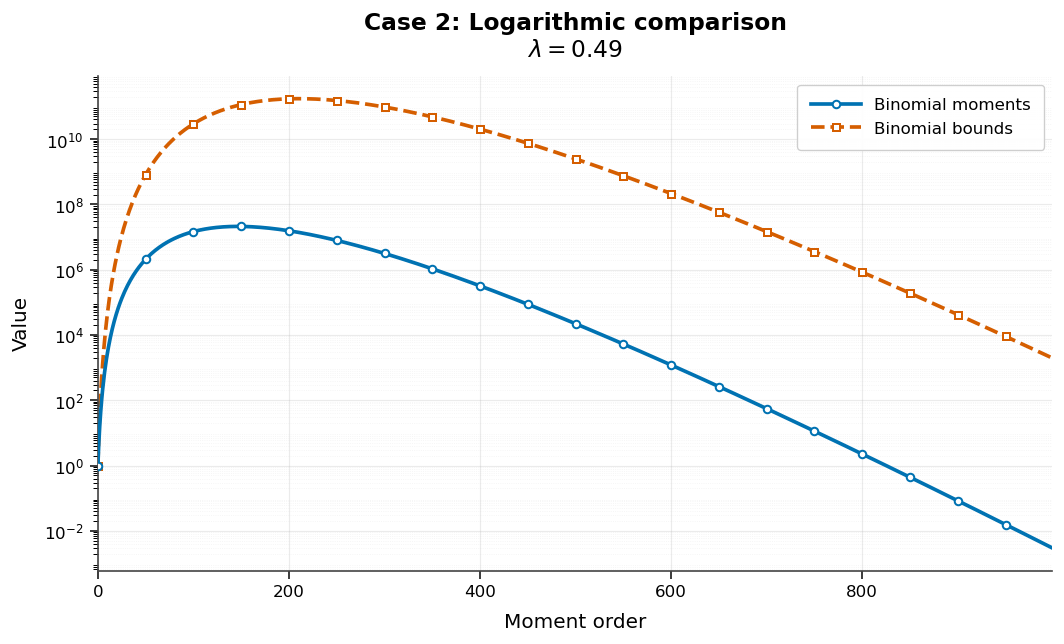

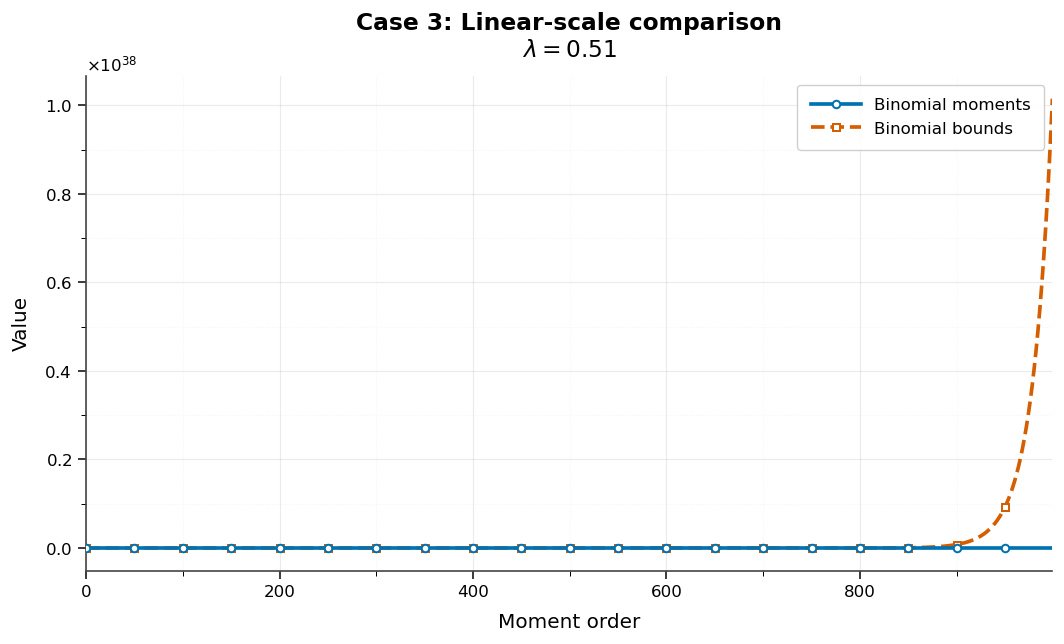

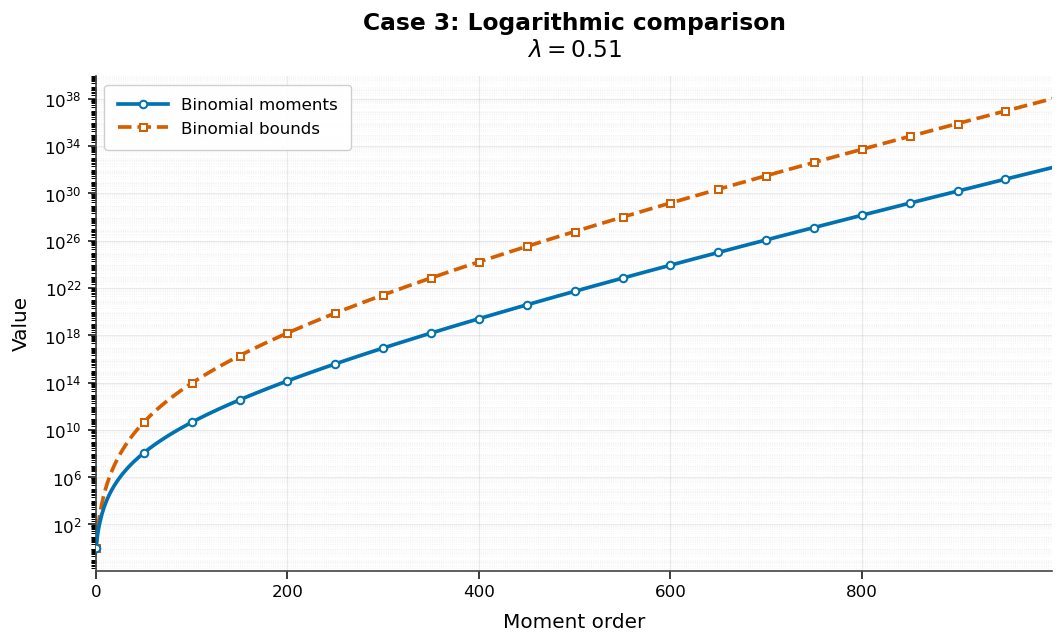

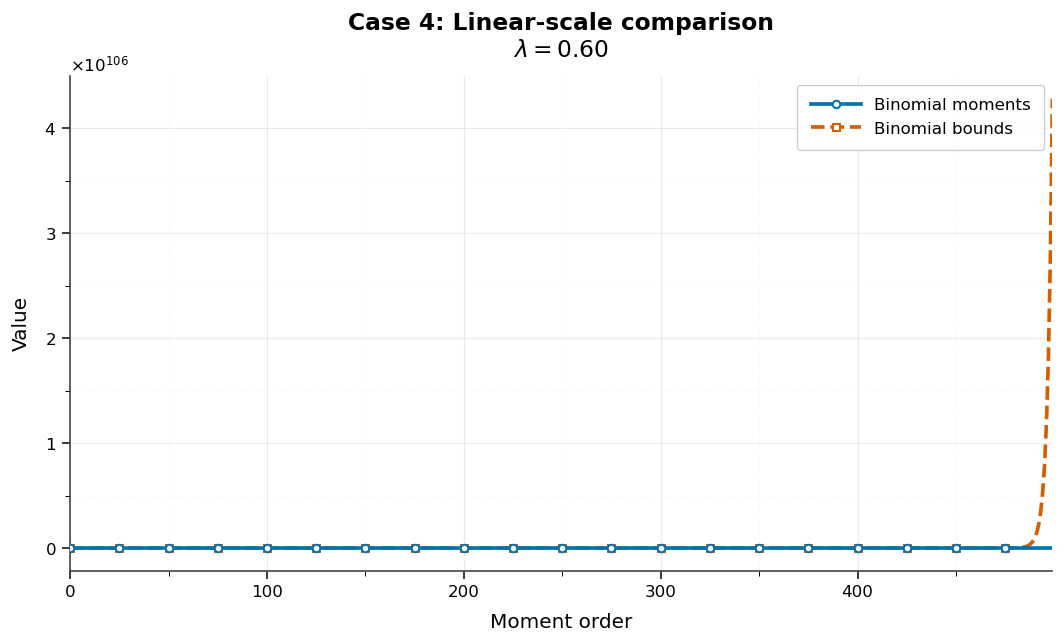

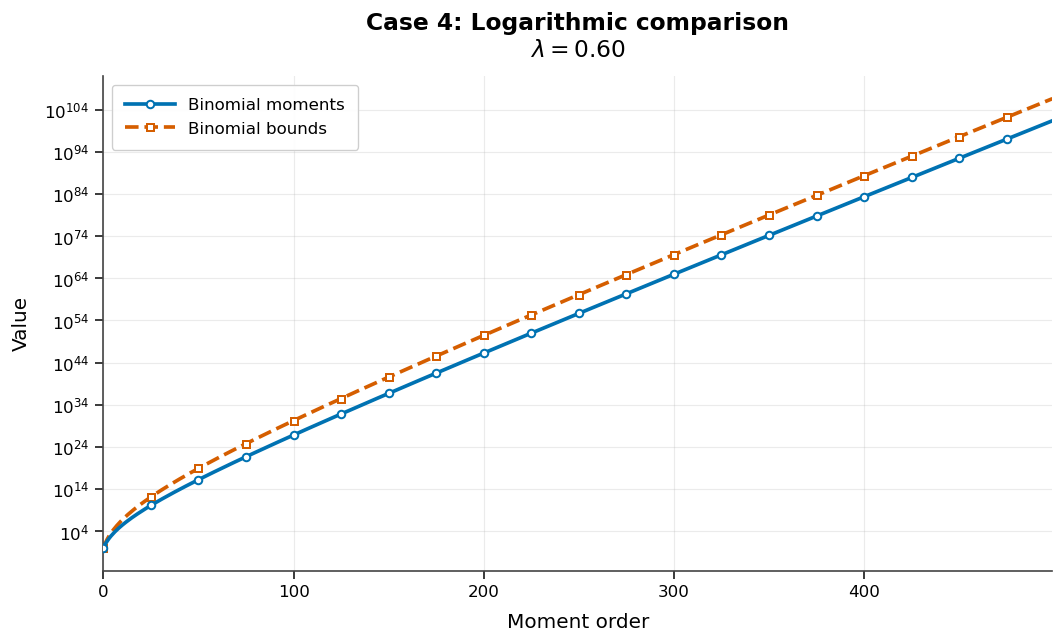

In [5]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import solve


np.set_printoptions(precision=8, suppress=True)


# Global execution options.
OUTPUT_DIR = Path("Binomial_Bound")
SAVE_RESULTS = True
PLOT_RESULTS = True
PRINT_FULL_SEQUENCES = False


@dataclass(frozen=True)
class CaseConfig:
    index: int
    name: str
    lam: float
    m_max: int
    plot_points: int
    delta: float = 1.0

    @property
    def moment_filename(self) -> str:
        return f"BM_real{self.index}.npy"

    @property
    def bound_filename(self) -> str:
        return f"BM_bound{self.index}.npy"


D0 = np.zeros((4, 4), dtype=float)

D1 = np.array(
    [
        [0.2, 0.2, 0.1, 0.8],
        [0.2, 0.2, 0.1, 0.8],
        [0.1, 0.1, 0.1, 0.0],
        [0.8, 0.8, 0.0, 0.8],
    ],
    dtype=float,
)

CASES = (
    CaseConfig(
        index=1,
        name="Case 1",
        lam=0.20,
        m_max=1000,
        plot_points=1000,
    ),
    CaseConfig(
        index=2,
        name="Case 2",
        lam=0.49,
        m_max=1100,
        plot_points=1000,
    ),
    CaseConfig(
        index=3,
        name="Case 3",
        lam=0.51,
        m_max=1010,
        plot_points=1000,
    ),
    CaseConfig(
        index=4,
        name="Case 4",
        lam=0.60,
        m_max=510,
        plot_points=500,
    ),
)


@dataclass
class CaseResult:
    config: CaseConfig
    generator: np.ndarray
    stationary: np.ndarray
    moments: np.ndarray
    bounds: np.ndarray
    stationary_residual: float


def validate_model(
    d0: np.ndarray,
    d1: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Validate and convert the two model matrices."""
    d0 = np.asarray(d0, dtype=float)
    d1 = np.asarray(d1, dtype=float)

    if d0.shape != d1.shape:
        raise ValueError("D0 and D1 must have identical shapes.")

    if d0.ndim != 2 or d0.shape[0] != d0.shape[1]:
        raise ValueError("D0 and D1 must be square matrices.")

    if not np.all(np.isfinite(d0)) or not np.all(np.isfinite(d1)):
        raise ValueError("D0 and D1 must contain only finite values.")

    return d0, d1


def validate_case(config: CaseConfig) -> None:
    """Validate one parameter set before running the calculation."""
    if not 0.0 < config.lam < 1.0:
        raise ValueError("lam must satisfy 0 < lam < 1.")

    if config.m_max < 0:
        raise ValueError("m_max must be non-negative.")

    if config.plot_points < 1:
        raise ValueError("plot_points must be at least 1.")

    if config.delta <= 0.0:
        raise ValueError("delta must be positive.")


def build_geometric_generator(
    d0: np.ndarray,
    d1: np.ndarray,
    lam: float,
) -> np.ndarray:
    """Construct the generator and enforce zero row sums."""
    generator = (
        np.asarray(d0, dtype=float)
        + np.asarray(d1, dtype=float) / (1.0 - lam)
    )
    generator = generator.copy()

    # Replace each diagonal entry with the negative sum
    # of its off-diagonal row.
    off_diagonal_sums = (
        generator.sum(axis=1)
        - np.diag(generator)
    )
    np.fill_diagonal(generator, -off_diagonal_sums)

    return generator


def stationary_distribution(
    generator: np.ndarray,
) -> np.ndarray:
    """Solve pi D = 0 together with sum(pi) = 1."""
    n_states = generator.shape[0]

    system = generator.T.copy()
    system[0, :] = 1.0

    rhs = np.zeros(n_states, dtype=float)
    rhs[0] = 1.0

    pi = solve(
        system,
        rhs,
        assume_a="gen",
        check_finite=False,
    )
    pi /= pi.sum()

    return pi


def solve_right(
    matrix: np.ndarray,
    rhs: np.ndarray,
) -> np.ndarray:
    """Return X satisfying X @ matrix = rhs.

    The right-sided matrix equation

        X M = Y

    is solved through the equivalent transposed system

        M.T X.T = Y.T.
    """
    return solve(
        matrix.T,
        rhs.T,
        assume_a="gen",
        check_finite=False,
    ).T


def compute_binomial_moments(
    generator: np.ndarray,
    d1: np.ndarray,
    lam: float,
    pi: np.ndarray,
    m_max: int,
    delta: float = 1.0,
) -> np.ndarray:
    """Compute B_0 through B_m_max using Algorithm S.1.

    For each m, the algorithm computes

        S_m = sum_{i=1}^m Z_{m-i} C_i,

    and then solves the right-sided matrix equation

        Z_m (m delta I - D) = S_m.

    For the geometric model,

        C_i = (lam / (1 - lam))^(i - 1)
              * D1 / (1 - lam)^2.

    All C_i matrices are generated directly before the main loop.
    No recursive convolution shortcut is used.
    """
    generator = np.asarray(generator, dtype=float)
    d1 = np.asarray(d1, dtype=float)
    pi = np.asarray(pi, dtype=float)

    n_states = generator.shape[0]

    identity = np.eye(n_states, dtype=float)
    ones = np.ones((n_states, 1), dtype=float)
    pi_row = pi.reshape(1, -1)

    c1 = d1 / (1.0 - lam) ** 2
    ratio = lam / (1.0 - lam)

    # Store C_0, C_1, ..., C_m_max.
    # C_0 is unused and is included only for convenient indexing.
    c_matrices = np.empty(
        (m_max + 1, n_states, n_states),
        dtype=float,
    )
    c_matrices[0] = np.zeros(
        (n_states, n_states),
        dtype=float,
    )

    if m_max > 0:
        geometric_powers = np.power(
            ratio,
            np.arange(m_max, dtype=float),
        )

        c_matrices[1:] = (
            geometric_powers[:, np.newaxis, np.newaxis]
            * c1
        )

    # Store Z_0, Z_1, ..., Z_m_max.
    z_matrices = np.empty(
        (m_max + 1, n_states, n_states),
        dtype=float,
    )
    z_matrices[0] = identity

    moments = np.empty(m_max + 1, dtype=float)
    moments[0] = 1.0

    for order in range(1, m_max + 1):
        convolution = np.zeros(
            (n_states, n_states),
            dtype=float,
        )

        for index in range(1, order + 1):
            convolution += (
                z_matrices[order - index]
                @ c_matrices[index]
            )

        coefficient = (
            order * delta * identity
            - generator
        )

        # Solve:
        #
        #     Z_m @ coefficient = convolution
        #
        # without explicitly forming coefficient^{-1}.
        z_matrices[order] = solve_right(
            matrix=coefficient,
            rhs=convolution,
        )

        moments[order] = (
            pi_row
            @ z_matrices[order]
            @ ones
        ).item()

    return moments


def compute_binomial_bounds(
    m_max: int,
    lam: float,
    d1_infinity_norm: float,
    delta: float = 1.0,
) -> np.ndarray:
    """Compute bounds a_0 through a_m_max with matching array length."""
    alpha = (
        d1_infinity_norm
        / (delta * lam * (1.0 - lam))
    )
    ratio = lam / (1.0 - lam)

    bounds = np.empty(m_max + 1, dtype=float)
    bounds[0] = 1.0

    with np.errstate(
        over="ignore",
        under="ignore",
        invalid="ignore",
    ):
        for order in range(m_max):
            bounds[order + 1] = (
                bounds[order]
                * ratio
                * (alpha + order)
                / (order + 1)
            )

    return bounds


def run_case(
    config: CaseConfig,
    d0: np.ndarray,
    d1: np.ndarray,
) -> CaseResult:
    """Run the complete calculation for one case."""
    validate_case(config)
    d0, d1 = validate_model(d0, d1)

    generator = build_geometric_generator(
        d0=d0,
        d1=d1,
        lam=config.lam,
    )

    pi = stationary_distribution(generator)

    moments = compute_binomial_moments(
        generator=generator,
        d1=d1,
        lam=config.lam,
        pi=pi,
        m_max=config.m_max,
        delta=config.delta,
    )

    bounds = compute_binomial_bounds(
        m_max=config.m_max,
        lam=config.lam,
        d1_infinity_norm=np.linalg.norm(
            d1,
            ord=np.inf,
        ),
        delta=config.delta,
    )

    residual = float(
        np.max(
            np.abs(pi @ generator)
        )
    )

    return CaseResult(
        config=config,
        generator=generator,
        stationary=pi,
        moments=moments,
        bounds=bounds,
        stationary_residual=residual,
    )


def print_numbered_sequence(
    label: str,
    values: np.ndarray,
) -> None:
    """Print every element using the format of the original notebooks."""
    for index, value in enumerate(values):
        print(
            f"{label}[{index:4d}] = "
            f"{float(value):.6e}"
        )


# Run all four cases.
results = {
    config.index: run_case(
        config=config,
        d0=D0,
        d1=D1,
    )
    for config in CASES
}


for result in results.values():
    config = result.config

    print(
        f"{config.name}: "
        f"lambda={config.lam:.2f}, "
        f"M_max={config.m_max}, "
        f"stationary={result.stationary}, "
        f"max|pi D|={result.stationary_residual:.3e}, "
        f"B_M={result.moments[-1]:.6e}, "
        f"bound_M={result.bounds[-1]:.6e}"
    )

    if PRINT_FULL_SEQUENCES:
        print_numbered_sequence(
            "moment",
            result.moments,
        )
        print_numbered_sequence(
            "bound",
            result.bounds,
        )
        print()


# Save numerical results.
def save_case_result(
    result: CaseResult,
    output_dir: Path,
) -> list[Path]:
    """Save moments and bounds for one case."""
    output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    moment_path = (
        output_dir
        / result.config.moment_filename
    )
    bound_path = (
        output_dir
        / result.config.bound_filename
    )

    np.save(
        moment_path,
        result.moments,
    )
    np.save(
        bound_path,
        result.bounds,
    )

    return [
        moment_path,
        bound_path,
    ]


if SAVE_RESULTS:
    saved_files = []

    for result in results.values():
        saved_files.extend(
            save_case_result(
                result,
                OUTPUT_DIR,
            )
        )

    print(
        f"Saved {len(saved_files)} files to: "
        f"{OUTPUT_DIR.resolve()}"
    )

    for path in saved_files:
        print(f"  {path}")


def finite_values(
    values: np.ndarray,
) -> np.ndarray:
    """Convert non-finite values to NaN for safe plotting."""
    array = np.asarray(
        values,
        dtype=float,
    ).copy()

    array[~np.isfinite(array)] = np.nan

    return array


def plot_moments_and_bounds(
    result: CaseResult,
) -> None:
    """Plot binomial moments and bounds using a publication-style layout."""
    from matplotlib.ticker import (
        AutoMinorLocator,
        LogLocator,
        NullFormatter,
        ScalarFormatter,
    )

    config = result.config

    point_count = min(
        config.plot_points,
        result.moments.size,
        result.bounds.size,
    )

    if point_count < 1:
        return

    orders = np.arange(point_count)

    moments = finite_values(
        result.moments[:point_count]
    )
    bounds = finite_values(
        result.bounds[:point_count]
    )

    # A restrained, colorblind-friendly palette.
    moment_color = "#0072B2"
    bound_color = "#D55E00"

    # Display only a limited number of markers when many points are plotted.
    marker_step = max(1, point_count // 20)

    def create_figure(
        moment_values: np.ndarray,
        bound_values: np.ndarray,
        *,
        logarithmic: bool,
    ) -> None:
        """Create one linear-scale or logarithmic-scale figure."""
        with plt.rc_context(
            {
                "font.size": 11,
                "axes.labelsize": 12,
                "axes.titlesize": 14,
                "legend.fontsize": 10,
                "xtick.labelsize": 10,
                "ytick.labelsize": 10,
                "axes.linewidth": 1.0,
            }
        ):
            fig, ax = plt.subplots(
                figsize=(9, 5.5),
                dpi=120,
            )

            ax.plot(
                orders,
                moment_values,
                color=moment_color,
                linewidth=2.2,
                marker="o",
                markersize=4.5,
                markevery=marker_step,
                markerfacecolor="white",
                markeredgewidth=1.2,
                label="Binomial moments",
                zorder=3,
            )

            ax.plot(
                orders,
                bound_values,
                color=bound_color,
                linewidth=2.2,
                linestyle="--",
                marker="s",
                markersize=4.2,
                markevery=marker_step,
                markerfacecolor="white",
                markeredgewidth=1.2,
                label="Binomial bounds",
                zorder=2,
            )

            if logarithmic:
                ax.set_yscale("log")

                ax.yaxis.set_major_locator(
                    LogLocator(
                        base=10.0,
                        numticks=12,
                    )
                )
                ax.yaxis.set_minor_locator(
                    LogLocator(
                        base=10.0,
                        subs=np.arange(2, 10) * 0.1,
                        numticks=100,
                    )
                )
                ax.yaxis.set_minor_formatter(
                    NullFormatter()
                )

                scale_title = "Logarithmic comparison"
            else:
                formatter = ScalarFormatter(
                    useMathText=True
                )
                formatter.set_powerlimits((-3, 4))

                ax.yaxis.set_major_formatter(
                    formatter
                )
                ax.xaxis.set_minor_locator(
                    AutoMinorLocator(2)
                )
                ax.yaxis.set_minor_locator(
                    AutoMinorLocator(2)
                )

                scale_title = "Linear-scale comparison"

            ax.set_xlabel(
                "Moment order",
                labelpad=8,
            )
            ax.set_ylabel(
                "Value",
                labelpad=8,
            )

            ax.set_title(
                f"{config.name}: {scale_title}\n"
                f"$\\lambda={config.lam:.2f}$",
                pad=12,
                fontweight="semibold",
            )

            ax.set_xlim(
                orders[0],
                orders[-1] if point_count > 1 else orders[0] + 1,
            )

            # Remove unnecessary frame lines for a cleaner appearance.
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            ax.spines["left"].set_color("#444444")
            ax.spines["bottom"].set_color("#444444")

            ax.tick_params(
                axis="both",
                which="major",
                direction="out",
                length=5,
                width=0.9,
            )
            ax.tick_params(
                axis="both",
                which="minor",
                direction="out",
                length=3,
                width=0.6,
            )

            ax.grid(
                True,
                which="major",
                linestyle="-",
                linewidth=0.7,
                alpha=0.25,
            )
            ax.grid(
                True,
                which="minor",
                linestyle=":",
                linewidth=0.5,
                alpha=0.15,
            )

            legend = ax.legend(
                loc="best",
                frameon=True,
                fancybox=True,
                framealpha=0.95,
                borderpad=0.8,
                handlelength=3.0,
            )
            legend.get_frame().set_edgecolor("#CCCCCC")
            legend.get_frame().set_linewidth(0.8)

            fig.tight_layout()
            plt.show()
            plt.close(fig)

    # Linear-scale figure.
    create_figure(
        moment_values=moments,
        bound_values=bounds,
        logarithmic=False,
    )

    # Logarithmic axes require strictly positive finite values.
    positive_moments = np.where(
        np.isfinite(moments) & (moments > 0.0),
        moments,
        np.nan,
    )
    positive_bounds = np.where(
        np.isfinite(bounds) & (bounds > 0.0),
        bounds,
        np.nan,
    )

    if (
        np.any(np.isfinite(positive_moments))
        or np.any(np.isfinite(positive_bounds))
    ):
        create_figure(
            moment_values=positive_moments,
            bound_values=positive_bounds,
            logarithmic=True,
        )




if PLOT_RESULTS:
    for result in results.values():
        plot_moments_and_bounds(result)
